# From RA and Dec to a Galaxy

This notebook is built to **teach astronomy concepts clearly** and then connect them to Python.

Main idea:

1. Earth uses coordinates  
2. The sky also uses coordinates  
3. **RA** and **Dec** are how astronomers give a galaxy an address  
4. A telescope points using that address  
5. Python turns the image into measurements

## What are the sample files?

- **`sample_galaxy_data_v2.npy`** stores a grid of brightness values. This is the **math version** of a telescope image.  
- **`sample_galaxy_rgb_v2.png`** is a color image used for the color section. This is the **picture version**.

So:

- **NPY = numbers**  
- **PNG = picture**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

plt.rcParams['figure.figsize'] = (8, 6)

## 1. Start with a familiar idea: coordinates on Earth

A coordinate system is just a way to describe position.

On Earth we use:

- **latitude** to say how far north or south a place is  
- **longitude** to say how far east or west a place is

That lets every city have an address on a map.

Astronomers do the same thing for the sky.

### Earth and sky both need coordinate systems

Students usually understand maps first. That makes RA and Dec much easier to teach.

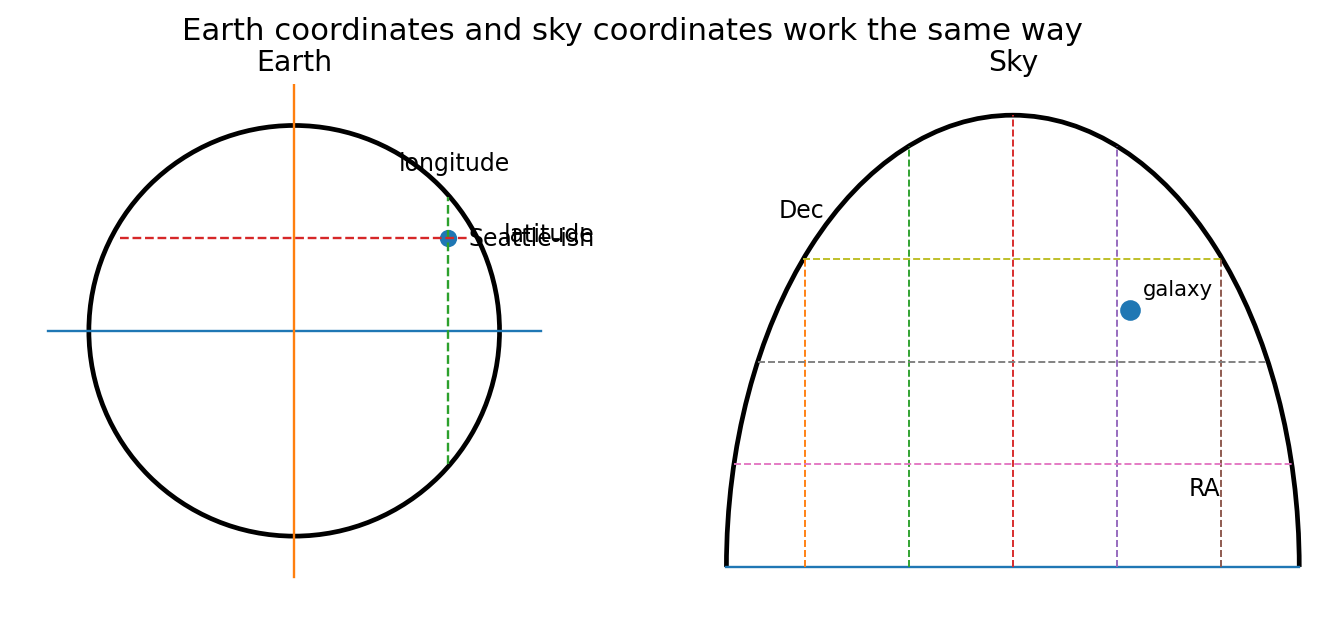

## 2. The sky also needs an address system

A telescope cannot find a galaxy by guesswork. The sky is too big.

Astronomers use two coordinates:

- **Right Ascension (RA)**  
- **Declination (Dec)**

Together they tell the telescope exactly where an object is.

## 3. Right Ascension, or RA

Right Ascension tells us where something is **around the sky**.

Think of RA as the sky version of longitude.

Important facts:

- RA goes all the way around the sky  
- RA is written in **hours, minutes, and seconds**  
- the full circle is **24 hours** of RA  
- **1 hour of RA = 15 degrees**

Why hours?

Because the sky appears to rotate as Earth spins. Astronomers historically connected position around the sky to a time-like system.

### RA is measured around the sky

Good line to say: **RA is not the current time. It is a coordinate that uses hours.**

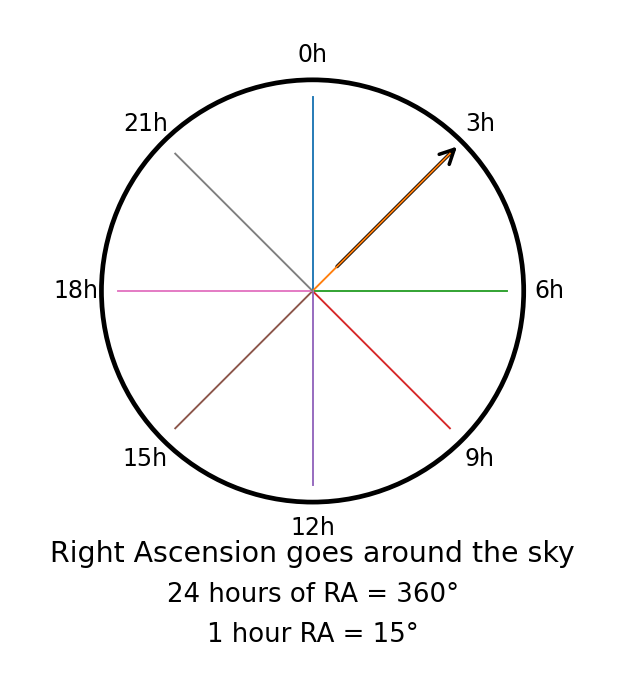

## 4. Declination, or Dec

Declination tells us how far **north or south** an object is in the sky.

Think of Dec as the sky version of latitude.

Important facts:

- Dec is written in **degrees**  
- **0° Dec** is the celestial equator  
- positive Dec is north  
- negative Dec is south

### Dec is measured in degrees north or south

Good line to say: **Dec tells us how far above or below the sky's equator an object is.**

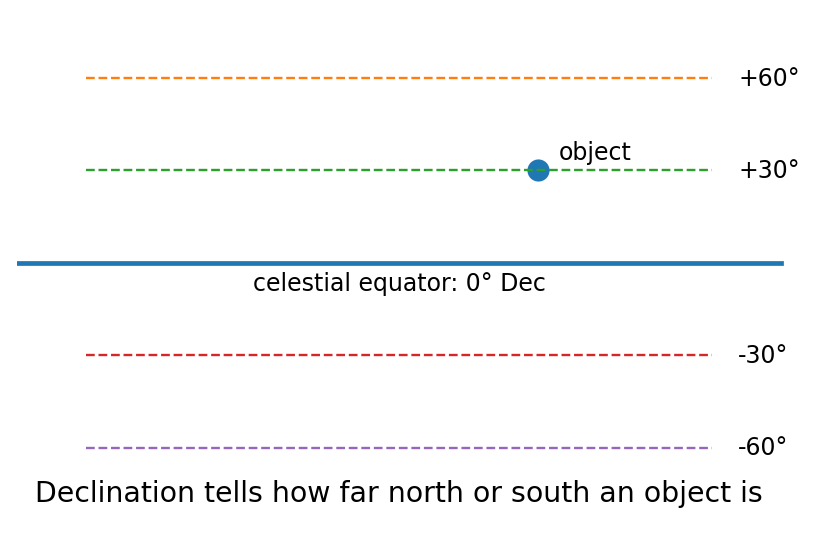

## 5. RA and Dec together make a sky address

You need both coordinates.

Example:

- Andromeda Galaxy is roughly at **RA 00h 42m, Dec +41°**

That means:

- RA chooses the position **around** the sky  
- Dec chooses the position **north or south**

### RA and Dec together tell the telescope where to point

This is the astronomy story you wanted: **we used RA and Dec to get the galaxy image in the first place.**

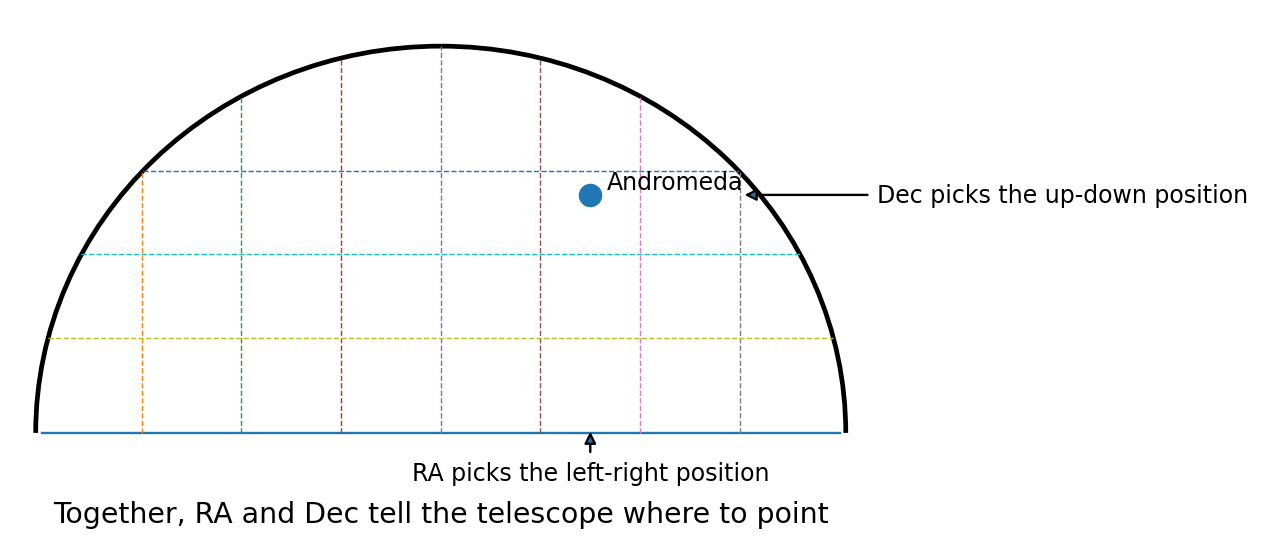

## 6. Converting RA and Dec into numbers Python can use

Astronomers often write coordinates like this:

- RA = 00h 42m 44s  
- Dec = +41° 16′ 9″

Python often works more easily with decimal degrees, so we convert them.

In [2]:
def hms_to_deg(hours, minutes=0, seconds=0):
    return 15 * (hours + minutes/60 + seconds/3600)

def dms_to_deg(degrees, arcmin=0, arcsec=0):
    sign = 1 if degrees >= 0 else -1
    return degrees + sign * arcmin/60 + sign * arcsec/3600

andromeda_ra_deg = hms_to_deg(0, 42, 44)
andromeda_dec_deg = dms_to_deg(41, 16, 9)

print('Andromeda RA in decimal degrees =', andromeda_ra_deg)
print('Andromeda Dec in decimal degrees =', andromeda_dec_deg)

Andromeda RA in decimal degrees = 10.683333333333334
Andromeda Dec in decimal degrees = 41.26916666666666


### What that conversion means

The galaxy did not move. We only changed **how we write the same address** so Python can calculate with it.

## 7. Angular separation

Once we know two sky positions, we can measure the angle between them.

This is called **angular separation**.

Important idea:

- angular separation is **not** the actual space distance  
- it is how far apart two things **look** on the sky

### Angular separation is an angle, not a true space distance

This is a common confusion, so it is worth saying twice.

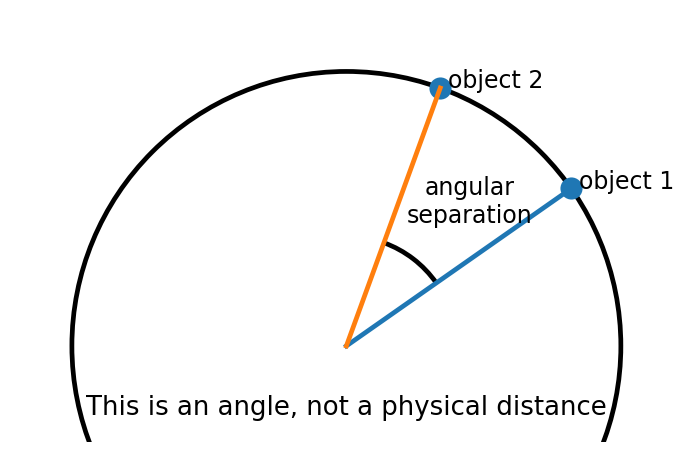

In [3]:
def angular_separation_deg(ra1_deg, dec1_deg, ra2_deg, dec2_deg):
    ra1 = np.radians(ra1_deg)
    dec1 = np.radians(dec1_deg)
    ra2 = np.radians(ra2_deg)
    dec2 = np.radians(dec2_deg)
    cos_sep = (np.sin(dec1) * np.sin(dec2) +
               np.cos(dec1) * np.cos(dec2) * np.cos(ra1 - ra2))
    cos_sep = np.clip(cos_sep, -1, 1)
    return np.degrees(np.arccos(cos_sep))

ra2_deg = 10.7000
dec2_deg = 41.3000
sep_deg = angular_separation_deg(andromeda_ra_deg, andromeda_dec_deg, ra2_deg, dec2_deg)

print('Angular separation in degrees =', sep_deg)
print('Angular separation in arcminutes =', sep_deg * 60)
print('Angular separation in arcseconds =', sep_deg * 3600)

Angular separation in degrees = 0.03327980941573798
Angular separation in arcminutes = 1.9967885649442787
Angular separation in arcseconds = 119.80731389665672


## 8. Why RA and Dec matter for the telescope

The telescope does not start with a pretty picture. It starts with coordinates.

Workflow:

1. choose a target galaxy  
2. find its RA and Dec  
3. point the telescope  
4. capture the image  
5. analyze the image with Python

So RA and Dec are part of the science, not just labels.

## 9. A telescope image is a grid of numbers

After the telescope captures the galaxy, each pixel stores a brightness value.

That means the image is both:

- a picture you can look at  
- data you can measure

### Each pixel stores brightness data

This is the bridge from astronomy into coding.

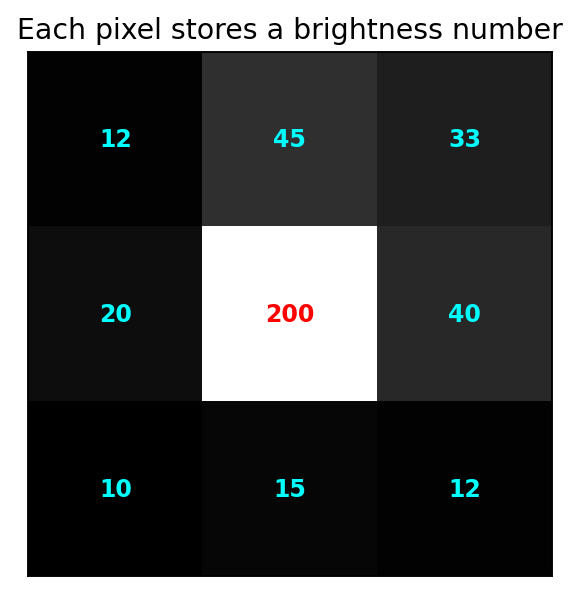

Image shape: (512, 512)


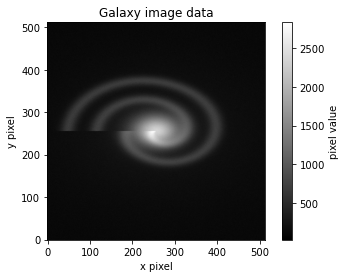

In [4]:
data_file = Path(r'sample_galaxy_data_v2.npy')
rgb_file = Path(r'sample_galaxy_rgb_v2.png')

data = np.load(data_file)
print('Image shape:', data.shape)

plt.imshow(data, cmap='gray', origin='lower')
plt.colorbar(label='pixel value')
plt.title('Galaxy image data')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.show()

## 10. Brightness

A simple astronomy question is: **how much light came from this part of the galaxy?**

A first method is to add up the pixel values in a chosen region.

That is a beginner version of **photometry**.

Total brightness in selected region = 3464270.5
Average brightness per pixel = 2165.169


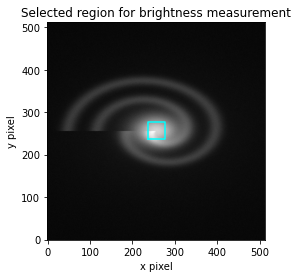

In [5]:
x_center = 256
y_center = 256
half_size = 20

region = data[y_center-half_size:y_center+half_size, x_center-half_size:x_center+half_size]
brightness = np.sum(region)

print('Total brightness in selected region =', brightness)
print('Average brightness per pixel =', np.mean(region))

plt.imshow(data, cmap='gray', origin='lower')
plt.plot([x_center-half_size, x_center+half_size, x_center+half_size, x_center-half_size, x_center-half_size],
         [y_center-half_size, y_center-half_size, y_center+half_size, y_center+half_size, y_center-half_size],
         color='cyan')
plt.title('Selected region for brightness measurement')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.show()

## 11. Brightness map

A heatmap helps students see where the galaxy is brighter and dimmer.

Usually the center is brighter because many stars are packed together.

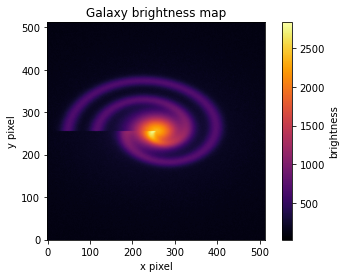

In [6]:
plt.imshow(data, cmap='inferno', origin='lower')
plt.colorbar(label='brightness')
plt.title('Galaxy brightness map')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.show()

## 12. Apparent size

There are two different ideas:

- **apparent size** means how big the object looks on the sky  
- **true size** means how big it really is in space

From an image, we usually measure **apparent size** first.

### Apparent size means how big it looks

That is why the output is in arcseconds, not miles or light-years.

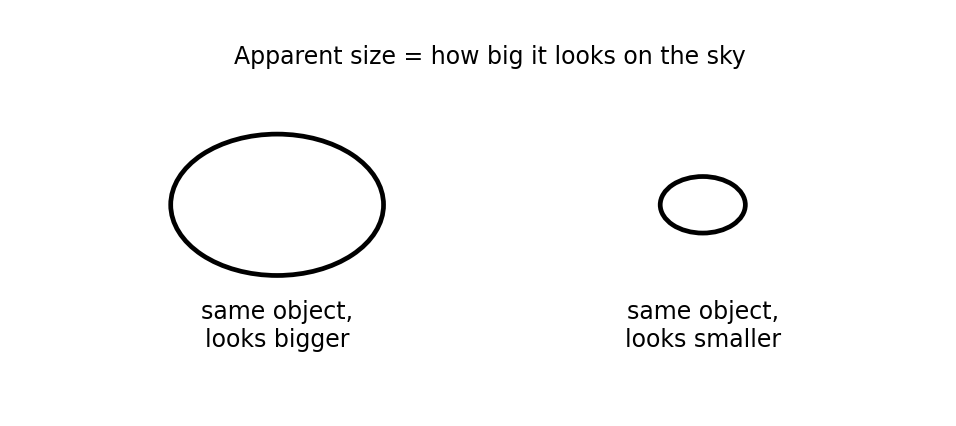

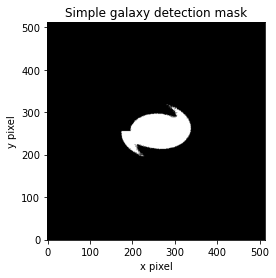

Estimated width in pixels = 163
Estimated height in pixels = 121
Estimated angular width = 244.5 arcseconds
Estimated angular height = 181.5 arcseconds


In [7]:
threshold = np.mean(data) + 2*np.std(data)
mask = data > threshold

plt.imshow(mask, cmap='gray', origin='lower')
plt.title('Simple galaxy detection mask')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.show()

ys, xs = np.where(mask)
x_width_pixels = xs.max() - xs.min()
y_height_pixels = ys.max() - ys.min()
arcsec_per_pixel = 1.5  # example value

print('Estimated width in pixels =', x_width_pixels)
print('Estimated height in pixels =', y_height_pixels)
print('Estimated angular width =', x_width_pixels * arcsec_per_pixel, 'arcseconds')
print('Estimated angular height =', y_height_pixels * arcsec_per_pixel, 'arcseconds')

## 13. Brightness profile

A galaxy is not equally bright everywhere. A brightness profile shows how average brightness changes as you move outward from the center.

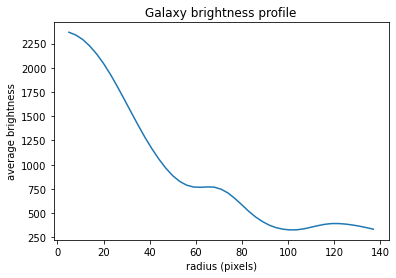

In [8]:
center_x, center_y = 256, 256
max_radius = 140

yy, xx = np.indices(data.shape)
rr = np.sqrt((xx - center_x)**2 + (yy - center_y)**2)
radii = []
means = []

for r in range(5, max_radius, 3):
    annulus = (rr >= r-2) & (rr < r+2)
    radii.append(r)
    means.append(np.mean(data[annulus]))

plt.plot(radii, means)
plt.xlabel('radius (pixels)')
plt.ylabel('average brightness')
plt.title('Galaxy brightness profile')
plt.show()

## 14. Color clues

Color gives another astronomy clue.

For a middle-school level explanation:

- **bluer regions** can mean younger, hotter stars  
- **redder regions** can mean older, cooler stars

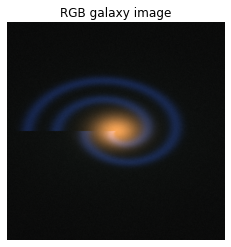

Average R = 0.07527530146580118
Average G = 0.07888968972598805
Average B = 0.08356427959367341


In [9]:
img = np.array(Image.open(rgb_file)).astype(float)
if img.max() > 1.0:
    img = img / 255.0

plt.imshow(img, origin='lower')
plt.title('RGB galaxy image')
plt.axis('off')
plt.show()

R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]
print('Average R =', np.mean(R))
print('Average G =', np.mean(G))
print('Average B =', np.mean(B))

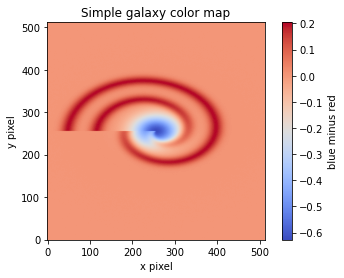

In [10]:
color_map = B - R
plt.imshow(color_map, cmap='coolwarm', origin='lower')
plt.colorbar(label='blue minus red')
plt.title('Simple galaxy color map')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.show()

## 15. Suggested lines to say out loud

- RA and Dec are the sky's address system.  
- RA tells us where something is around the sky.  
- Dec tells us how far north or south it is.  
- Together they let the telescope point to a galaxy.  
- After we get the image, Python helps us measure brightness, apparent size, and color clues.

## 16. Put the whole astronomy workflow together

At this point, students have seen the full chain:

1. **RA and Dec** give the galaxy a sky address  
2. the telescope points to that address  
3. the telescope captures an image  
4. each pixel stores brightness data  
5. Python helps us measure brightness, apparent size, and color clues

That is a real astronomy workflow. The main difference between this lesson and professional astronomy is mostly the scale and precision, not the basic logic.

## 17. What students should understand by the end

By the end of this notebook, students should be able to explain:

- **why astronomers need coordinates**  
- **what Right Ascension means**  
- **what Declination means**  
- **how a telescope uses RA and Dec to find an object**  
- **why an image is also data**  
- **how Python can measure things from a galaxy image**

## 18. Common misconceptions to fix out loud

These are the places where students often get confused:

### Misconception 1
**RA is the time right now.**  
No. RA is a coordinate. It uses hours, but it is not the current clock time.

### Misconception 2
**Angular separation means true space distance.**  
No. Angular separation only tells us how far apart things look on the sky.

### Misconception 3
**The telescope gives us science automatically.**  
Not exactly. The telescope gives us data, and then we use math and code to turn that data into measurements.

### Misconception 4
**A color image gives exact physical answers by itself.**  
Not exactly. Color gives clues, but careful scientific measurements usually need calibration.

## 19. Mini glossary

- **RA**: Right Ascension, the sky version of longitude  
- **Dec**: Declination, the sky version of latitude  
- **pixel**: one tiny square in an image that stores a brightness value  
- **photometry**: measuring light  
- **angular separation**: the angle between two sky positions  
- **apparent size**: how big something looks in the sky  
- **brightness profile**: how brightness changes from the center outward

## 20. Practice questions for students

Try asking these during the presentation:

1. Why do astronomers need RA and Dec instead of just saying 'over there'?  
2. If RA is like longitude, what is Dec like?  
3. Why is RA written in hours instead of only degrees?  
4. If two objects have a small angular separation, what does that mean?  
5. Why do we say a telescope image is also data?  
6. What does adding pixel values tell us?  
7. What is the difference between apparent size and true size?

## 21. Challenge activities

Here are a few ways students can keep exploring:

- change the selected box and compare brightness in two different parts of the galaxy  
- try a different threshold and see how the measured apparent size changes  
- compare the galaxy center to a spiral arm  
- change the second RA and Dec position and recompute the angular separation  
- find the brightest pixel in the image

Brightest pixel at: (249, 255)
Brightest pixel value: 2828.261


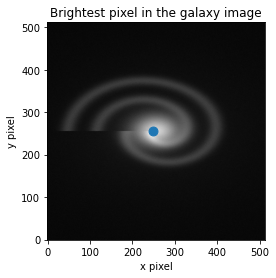

In [11]:
y_max, x_max = np.unravel_index(np.argmax(data), data.shape)
print('Brightest pixel at:', (x_max, y_max))
print('Brightest pixel value:', data[y_max, x_max])

plt.imshow(data, cmap='gray', origin='lower')
plt.scatter([x_max], [y_max], s=80)
plt.title('Brightest pixel in the galaxy image')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.show()

## 22. If you want to swap in real Seestar files later

This notebook uses sample files so it is reliable for teaching.

Later, you can replace them with your own files:

- replace the sample NPY file with your real telescope data source  
- replace the sample PNG with your real exported color image  
- if you have a FITS file, it can be added in a later version of the notebook

That way, the same lesson structure can stay the same while the data becomes your own.

## 23. Final takeaway

The biggest idea in this notebook is simple:

**Astronomy is not only about looking at space. It is about locating things precisely, collecting data, and using math to understand what the image means.**

That is why RA and Dec matter. They are the start of the whole story.

## 24. One-sentence ending for your presentation

You can end with:

> We used RA and Dec to find a galaxy, then we used Python to turn its image into science.